In [2]:
"""
Bistability with NaP

Reference:
Wang X-J (2008)
Attractor network models
In Encyclopedia of Neuroscience, volume 1, pp. 667-679 Edited by Squire LR. Oxford: Academic Press.

@author: Guangyu Robert Yang @ 2017/4

"""
from __future__ import division
from collections import OrderedDict
import random as pyrand # Import before Brian floods the namespace

# Once your code is working, turn units off for speed
# import brian_no_units

from brian2 import *

Starting simulation at t=0. s for a duration of 0.5 s
0.5 s (100%) simulated in < 1s


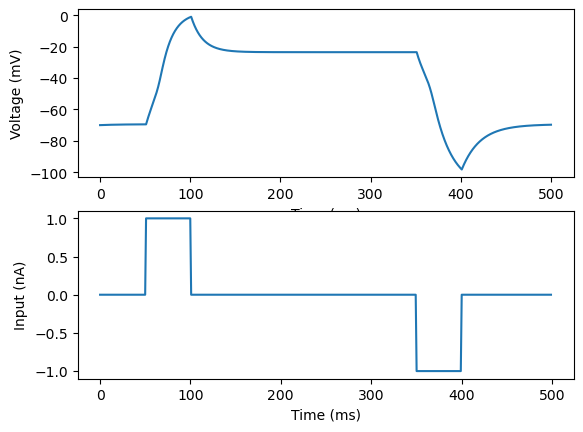

In [31]:

 

#=========================================================================================
# Equations
#=========================================================================================

equation = '''
dV/dt  = (-g_L*(V-V_L) - g_NaP*m_NaP*(V-V_Na) + I_ext(t)) / C_m : volt
m_NaP  = 1./(1 + exp(-(V + 45*mV)/(5*mV))) : 1

V_L    : volt (constant)
Vth    : volt (constant)
Vreset : volt (constant)
g_L    : siemens (constant)
C_m    : farad (constant)
tau_ref: second (constant)
V_Na   : volt (constant)
g_NaP  : siemens (constant)
'''

#=========================================================================================
# Model Parameters
#=========================================================================================

modelparamsLIF = dict(
    V_L    = -70*mV,
    Vth    = 100*mV, # disabling spiking
    Vreset = -55*mV,

    g_L    = 25*nS,
    #tau_m  = 20*ms,
    C_m    = 0.5*nF,
    tau_ref= 2*ms,

    V_Na   = 55*mV,
    g_NaP  = 15*nS
    )

#=========================================================================================
# Model
#=========================================================================================

class Model(object):
    def __init__(self, modelparams='LIF', dt=0.02*ms, n_neuron=1, stim=None):
        #---------------------------------------------------------------------------------
        # Initialize
        #---------------------------------------------------------------------------------

        # Create clocks
        clocks         = OrderedDict()
        clocks['main'] = Clock(dt)
        clocks['mons'] = Clock(0.1*ms)

        

        #---------------------------------------------------------------------------------
        # Complete the model specification
        #---------------------------------------------------------------------------------

        # Model parameters
        if isinstance(modelparams, str):
            if modelparams == 'LIF':
                params = modelparamsLIF.copy()
            else:
                raise ValueError('Unknown model params')
        elif isinstance(modelparams, dict):
            params = modelparams.copy()
        else:
            raise ValueError('Unknown modelparams type')

        #---------------------------------------------------------------------------------
        # Neuron populations
        #---------------------------------------------------------------------------------

        net = OrderedDict() # Network objects

        if stim is None:
            stim = TimedArray(np.zeros(1) * amp, dt=1*ms)
        namespace = {'I_ext': stim}
        
        net['neuron'] = NeuronGroup(
            n_neuron,
            equation,
            threshold='V > Vth',
            reset='V = Vreset',
            refractory='tau_ref',
            clock=clocks['main'],
            method='euler',
            namespace=namespace
        )
        net['neuron'].V = params['V_L']

        for key, value in params.items():
            setattr(net['neuron'], key, value)
        #---------------------------------------------------------------------------------
        # External input
        #---------------------------------------------------------------------------------

        


        #---------------------------------------------------------------------------------
        # Record spikes
        #---------------------------------------------------------------------------------

        mons = OrderedDict()
        var_list = ['V']
        mons['spike'] = SpikeMonitor(net['neuron'], record=True)
        mons['pop'] = PopulationRateMonitor(net['neuron'])
        for var in var_list:
            mons[var] = StateMonitor(net['neuron'], var, record=True, clock=clocks['mons'])

        #---------------------------------------------------------------------------------
        # Setup
        #---------------------------------------------------------------------------------

        self.params     = params
        self.net        = net
        self.mons       = mons
        self.clocks     = clocks
        self.n_neuron   = n_neuron

        

    def reinit(self, seed=123):
        # Re-initialize random number generators
        pyrand.seed(seed)
        np.random.seed(seed)

        pyrand.seed(seed)
        np.random.seed(seed)
        

        # Randomly initialize membrane potentials
        self.net['neuron'].V = self.params['V_L']

#/////////////////////////////////////////////////////////////////////////////////////////

if __name__ == '__main__':
    dt = 0.02*ms
    T  = 0.5*second
    n_neuron = 1
    modelparams = 'LIF'

    # Set up the stimulus
    dt_stim = 1*ms
    i_stim  = int(T/dt_stim)+1
    t_stim  = np.arange(i_stim)/i_stim*T
    stim    = np.zeros(len(t_stim)) * amp
    stim[(50*ms<t_stim)*(t_stim<100*ms)]  = 1.0*nA
    stim[(350*ms<t_stim)*(t_stim<400*ms)] =-1.0*nA
    stim_    = TimedArray(stim, dt=dt_stim)

    # Setup the network
    model   = Model(modelparams, dt, n_neuron, stim_)
    network = Network(
        *list(model.net.values()),
        *list(model.mons.values())
    )
    model.reinit(seed=1234)

    # Run the network
    network.run(T, report='text')

    # Plot the results
    plt.figure()
    plt.subplot(2, 1, 1)
    plt.plot(model.mons['V'].t/ms, model.mons['V'].V[0]/mV)
    plt.xlabel('Time (ms)')
    plt.ylabel('Voltage (mV)')
    plt.subplot(2, 1, 2)
    plt.plot(t_stim/ms, stim/nA)
    plt.xlabel('Time (ms)')
    plt.ylabel('Input (nA)')
    plt.savefig('Bistability_NaP_trace.pdf')
    plt.show()